# Multinomial Naive Bayes - Reuters Dataset

In [17]:
import re
import math
from collections import Counter

import numpy as np
import pandas as pd
import nltk

In [18]:
try:
    from nltk.corpus import reuters
    _ = reuters.fileids()
except LookupError:
    nltk.download('reuters')
    from nltk.corpus import reuters

fileids = reuters.fileids()
print('Total documents in Reuters corpus:', len(fileids))

Total documents in Reuters corpus: 10788


In [19]:
texts = []
labels = []

for fid in fileids:
    cats = reuters.categories(fid)
    if len(cats) == 1:
        text = reuters.raw(fid)
        if text and text.strip():
            texts.append(text)
            labels.append(cats[0])

print('Single-label docs:', len(texts))
print('Unique classes   :', len(set(labels)))

Single-label docs: 9160
Unique classes   : 65


In [20]:
top_n_classes = 8
class_counts = Counter(labels)
top_classes = [c for c, _ in class_counts.most_common(top_n_classes)]

filtered_texts = []
filtered_labels = []
for t, y in zip(texts, labels):
    if y in top_classes:
        filtered_texts.append(t)
        filtered_labels.append(y)

print('Using top classes:', top_classes)
print('Filtered docs    :', len(filtered_texts))

Using top classes: ['earn', 'acq', 'crude', 'trade', 'money-fx', 'interest', 'money-supply', 'ship']
Filtered docs    : 7791


In [21]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def tokenize(text):
    text = clean_text(text)
    tokens = text.split()
    return [t for t in tokens if len(t) > 1]


def split_train_test(texts, labels, test_size=0.2, random_state=42):
    rng = np.random.default_rng(seed=random_state)
    indices = np.arange(len(texts))
    rng.shuffle(indices)

    test_count = int(len(texts) * test_size)
    test_idx = indices[:test_count]
    train_idx = indices[test_count:]

    x_train = [texts[i] for i in train_idx]
    y_train = [labels[i] for i in train_idx]
    x_test = [texts[i] for i in test_idx]
    y_test = [labels[i] for i in test_idx]

    return x_train, x_test, y_train, y_test

In [22]:
class MultinomialNaiveBayes:
    def __init__(self, alpha=1.0, min_token_freq=2):
        self.alpha = alpha
        self.min_token_freq = min_token_freq

        self.classes_ = []
        self.class_doc_count_ = Counter()
        self.class_log_prior_ = {}

        self.vocab_ = {}
        self.vocab_size_ = 0

        self.class_word_counts_ = {}
        self.class_total_words_ = {}

    def _build_vocab(self, tokenized_texts):
        global_counts = Counter()
        for tokens in tokenized_texts:
            global_counts.update(tokens)

        vocab_tokens = [w for w, c in global_counts.items() if c >= self.min_token_freq]
        vocab_tokens.sort()
        self.vocab_ = {w: i for i, w in enumerate(vocab_tokens)}
        self.vocab_size_ = len(self.vocab_)

    def fit(self, texts, labels):
        labels = list(labels)
        tokenized = [tokenize(t) for t in texts]

        self._build_vocab(tokenized)
        self.classes_ = sorted(set(labels))

        n_docs = len(texts)
        for c in self.classes_:
            self.class_word_counts_[c] = np.zeros(self.vocab_size_, dtype=np.float64)
            self.class_total_words_[c] = 0.0

        for tokens, c in zip(tokenized, labels):
            self.class_doc_count_[c] += 1
            for w in tokens:
                idx = self.vocab_.get(w)
                if idx is not None:
                    self.class_word_counts_[c][idx] += 1.0
                    self.class_total_words_[c] += 1.0

        for c in self.classes_:
            self.class_log_prior_[c] = math.log(self.class_doc_count_[c] / n_docs)

    def _predict_one(self, text):
        tokens = tokenize(text)
        token_counts = Counter(w for w in tokens if w in self.vocab_)

        best_class = None
        best_score = -float('inf')

        for c in self.classes_:
            log_prob = self.class_log_prior_[c]
            denom = self.class_total_words_[c] + self.alpha * self.vocab_size_

            word_count_vec = self.class_word_counts_[c]
            for w, cnt in token_counts.items():
                idx = self.vocab_[w]
                num = word_count_vec[idx] + self.alpha
                log_prob += cnt * math.log(num / denom)

            if log_prob > best_score:
                best_score = log_prob
                best_class = c

        return best_class

    def predict(self, texts):
        return [self._predict_one(t) for t in texts]

In [23]:
def confusion_matrix_manual(y_true, y_pred, class_names):
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    cm = np.zeros((len(class_names), len(class_names)), dtype=int)

    for t, p in zip(y_true, y_pred):
        if (t in class_to_idx) and (p in class_to_idx):
            cm[class_to_idx[t], class_to_idx[p]] += 1

    return cm


def metrics_from_confusion_matrix(cm):
    total = cm.sum()
    correct = np.trace(cm)
    accuracy = correct / total if total > 0 else 0.0

    precisions = []
    recalls = []

    n_classes = cm.shape[0]
    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        precisions.append(p)
        recalls.append(r)

    macro_precision = float(np.mean(precisions)) if precisions else 0.0
    macro_recall = float(np.mean(recalls)) if recalls else 0.0

    return accuracy, macro_precision, macro_recall, precisions, recalls

In [24]:
x_train, x_test, y_train, y_test = split_train_test(
    filtered_texts, filtered_labels, test_size=0.2, random_state=42
)

model = MultinomialNaiveBayes(alpha=1.0, min_token_freq=2)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

class_names = sorted(set(y_train) | set(y_test))
cm = confusion_matrix_manual(y_test, y_pred, class_names)
accuracy, macro_precision, macro_recall, cls_p, cls_r = metrics_from_confusion_matrix(cm)

print('Train docs      :', len(x_train))
print('Test docs       :', len(x_test))
print('Vocabulary size :', model.vocab_size_)
print(f'Accuracy        : {accuracy * 100:.2f}%')
print(f'Macro Precision : {macro_precision * 100:.2f}%')
print(f'Macro Recall    : {macro_recall * 100:.2f}%')

Train docs      : 6233
Test docs       : 1558
Vocabulary size : 14014
Accuracy        : 93.39%
Macro Precision : 88.40%
Macro Recall    : 85.53%


In [25]:
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df

,acq,crude,earn,interest,money-fx,money-supply,ship,trade
acq,463,0,5,0,0,0,0,1
crude,1,81,1,0,0,0,1,2
earn,38,5,723,0,4,0,0,2
interest,0,0,1,33,9,1,0,0
money-fx,0,0,2,2,45,2,0,3
money-supply,0,0,1,1,3,31,0,0
ship,3,6,0,0,0,0,20,3
trade,0,0,1,0,4,1,0,59


In [26]:
report_df = pd.DataFrame({
    'class': class_names,
    'precision': cls_p,
    'recall': cls_r
})
report_df

,class,precision,recall
0,acq,0.916832,0.987207
1,crude,0.880435,0.941860
2,earn,0.985014,0.936528
3,interest,0.916667,0.750000
4,money-fx,0.692308,0.833333
5,money-supply,0.885714,0.861111
6,ship,0.952381,0.625000
7,trade,0.842857,0.907692


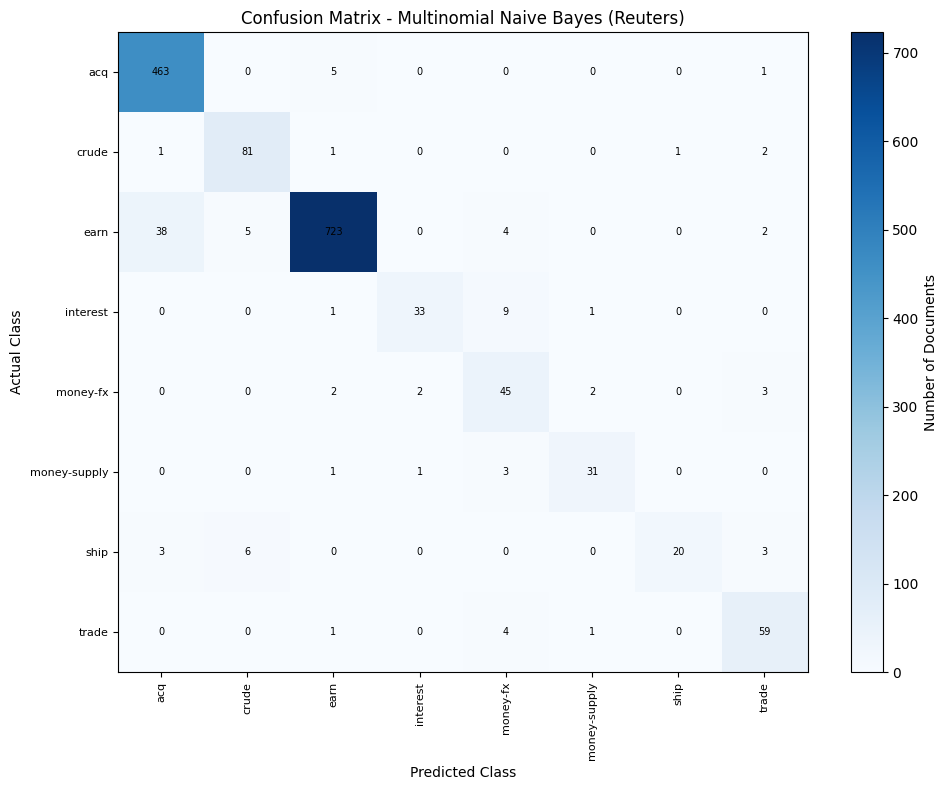

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

ax.set_title('Confusion Matrix - Multinomial Naive Bayes (Reuters)')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Actual Class')

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=90, fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=7)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Number of Documents')

plt.tight_layout()
plt.show()